# Variational Autoencoder — Step by Step

## Real-World Scenario: Generating Synthetic Single-Cells

A pharma team has measured gene expression on $N = 3000$ T-cells across $D = 64$ marker genes. They want to **generate plausible new cells** for two reasons:

1. *In silico* drug screening — sample novel cells, perturb their latent state, and ask the decoder what their expression profile would look like.
2. Imputation and smoothing — interpolate between two real cells along a biologically meaningful trajectory.

A plain autoencoder is great at **compressing** existing cells but offers no recipe for *sampling* — there is no distribution on the latent code. The **Variational Autoencoder** (VAE, §20.3.5) fixes this by turning the AE into a **probabilistic generative model**, trained via the **ELBO** with the **reparameterization trick**.

This notebook walks through every step of the construction:

1. The generative model $p_\theta(\mathbf{x},\mathbf{z})$
2. The intractable posterior $p_\theta(\mathbf{z}\mid\mathbf{x})$ and the variational approximation $q_\phi(\mathbf{z}\mid\mathbf{x})$
3. Three equivalent derivations of the **ELBO**
4. Closed-form KL between two diagonal Gaussians
5. Monte-Carlo estimation of the reconstruction term
6. Why backprop fails through a sample, and how the **reparameterization trick** fixes it
7. PyTorch implementation, training, and exploration of the latent space
8. Posterior collapse and the $\beta$-VAE

> Prerequisites: vanilla autoencoders (§20.3.1), KL divergence (§6.2), Gaussian densities (§3.2).

---


In [1]:
import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import FancyArrowPatch

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['axes.titlesize'] = 11
mpl.rcParams['axes.labelsize'] = 10

torch.manual_seed(0)
np.random.seed(0)


## Step 1 — The Generative Model

A VAE assumes data is **generated** from a low-dimensional latent code $\mathbf{z} \in \mathbb{R}^L$:

$$
\mathbf{z} \sim p(\mathbf{z}) = \mathcal{N}(\mathbf{0}, \mathbf{I}_L),
\qquad
\mathbf{x} \mid \mathbf{z} \sim p_\theta(\mathbf{x} \mid \mathbf{z}) = \mathcal{N}\!\big(\mathbf{x} \mid f_\theta(\mathbf{z}),\, \sigma^2 \mathbf{I}_D\big).
$$

- $p(\mathbf{z})$ is the **prior**: a standard isotropic Gaussian. Cheap to sample, easy to do KL against.
- $f_\theta : \mathbb{R}^L \to \mathbb{R}^D$ is a neural network — the **decoder** — with parameters $\theta$.
- $\sigma^2$ is a fixed (or learned) observation noise level.

The **marginal likelihood** is

$$
p_\theta(\mathbf{x}) = \int p_\theta(\mathbf{x} \mid \mathbf{z})\, p(\mathbf{z})\, d\mathbf{z}.
$$

This integral is **intractable** for any non-trivial $f_\theta$ — the decoder mixes Gaussians at infinitely many means $f_\theta(\mathbf{z})$, indexed by $\mathbf{z}$.

**Cell-biology mapping.** Think of $\mathbf{z}$ as 2 latent factors capturing cell-cycle phase and metabolic activity. The decoder $f_\theta$ converts those factors into a 64-gene expression profile.


## Step 2 — The Intractable Posterior

To **infer** the latent of a given cell we need

$$
p_\theta(\mathbf{z} \mid \mathbf{x}) = \frac{p_\theta(\mathbf{x} \mid \mathbf{z})\,p(\mathbf{z})}{p_\theta(\mathbf{x})}.
$$

The denominator is the same intractable integral. So we **approximate** the posterior with a tractable family — a diagonal Gaussian whose parameters are output by a second neural network, the **encoder**:

$$
q_\phi(\mathbf{z} \mid \mathbf{x}) = \mathcal{N}\!\big(\mathbf{z} \mid \boldsymbol{\mu}_\phi(\mathbf{x}),\, \mathrm{diag}(\boldsymbol{\sigma}^2_\phi(\mathbf{x}))\big).
$$

This is **amortized variational inference** (§10.1.5): instead of solving an optimisation problem per data point, the encoder learns to *predict* good variational parameters for any $\mathbf{x}$ in one forward pass.


## Step 3 — Deriving the ELBO

We want to maximise $\log p_\theta(\mathbf{x})$. Three equivalent derivations all land on the same lower bound.

### 3a) Jensen's inequality

For any distribution $q_\phi(\mathbf{z}\mid\mathbf{x}) > 0$,

$$
\log p_\theta(\mathbf{x}) = \log \int p_\theta(\mathbf{x},\mathbf{z}) \, d\mathbf{z}
= \log \int q_\phi(\mathbf{z}\mid\mathbf{x}) \, \frac{p_\theta(\mathbf{x},\mathbf{z})}{q_\phi(\mathbf{z}\mid\mathbf{x})} \, d\mathbf{z}.
$$

Apply Jensen ($\log \mathbb{E}[\cdot] \geq \mathbb{E}[\log \cdot]$):

$$
\log p_\theta(\mathbf{x}) \;\geq\; \mathbb{E}_{q_\phi}\!\left[\log \frac{p_\theta(\mathbf{x},\mathbf{z})}{q_\phi(\mathbf{z}\mid\mathbf{x})}\right] \;\equiv\; \mathcal{L}(\theta,\phi;\mathbf{x}).
$$

### 3b) The KL identity

Equivalently, write the log-evidence as

$$
\log p_\theta(\mathbf{x}) = \mathcal{L}(\theta,\phi;\mathbf{x}) + D_{\mathrm{KL}}\!\big(q_\phi(\mathbf{z}\mid\mathbf{x}) \,\|\, p_\theta(\mathbf{z}\mid\mathbf{x})\big).
$$

Because $D_{\mathrm{KL}} \geq 0$, **maximising $\mathcal{L}$ pushes $q_\phi$ towards the true posterior** while pushing $\log p_\theta(\mathbf{x})$ up. The gap is exactly the posterior-approximation error.

### 3c) The form we will optimise

Split $\log p_\theta(\mathbf{x},\mathbf{z}) = \log p_\theta(\mathbf{x}\mid\mathbf{z}) + \log p(\mathbf{z})$:

$$
\boxed{\;
\mathcal{L}(\theta,\phi;\mathbf{x})
= \underbrace{\mathbb{E}_{q_\phi}\!\big[\log p_\theta(\mathbf{x}\mid\mathbf{z})\big]}_{\text{reconstruction}}
\;-\;
\underbrace{D_{\mathrm{KL}}\!\big(q_\phi(\mathbf{z}\mid\mathbf{x}) \,\|\, p(\mathbf{z})\big)}_{\text{regularisation}}\;}
$$

This is the form a VAE optimises (§20.3.5.1, Eq. 20.98). Two intuitive jobs:

- **Reconstruct** the input well under the decoder (likelihood of $\mathbf{x}$ given a sample $\mathbf{z} \sim q_\phi$).
- **Stay close to the prior** — the encoder cannot collapse to a point or run off to infinity.


## Step 4 — KL Between Two Diagonal Gaussians (Closed Form)

The regulariser $D_{\mathrm{KL}}(q_\phi \,\|\, p)$ is between two Gaussians and has a **closed-form**, so we never need a Monte-Carlo estimate for it. For

$$
q_\phi = \mathcal{N}(\boldsymbol{\mu}, \mathrm{diag}(\boldsymbol{\sigma}^2)),
\qquad
p = \mathcal{N}(\mathbf{0}, \mathbf{I}_L),
$$

we have

$$
D_{\mathrm{KL}}(q_\phi \,\|\, p) = \tfrac{1}{2} \sum_{\ell=1}^L \big(\,\mu_\ell^2 + \sigma_\ell^2 - 1 - \log \sigma_\ell^2\,\big).
$$

**Sketch of the derivation** (one dimension, then sum because $q_\phi$ and $p$ both factorise across $\ell$):

$$
\begin{aligned}
D_{\mathrm{KL}}(q\|p)
&= \int q(z)\,[\log q(z) - \log p(z)]\,dz \\
&= \mathbb{E}_q\!\left[-\tfrac{1}{2}\log(2\pi\sigma^2) - \tfrac{(z-\mu)^2}{2\sigma^2}\right]
 - \mathbb{E}_q\!\left[-\tfrac{1}{2}\log(2\pi) - \tfrac{z^2}{2}\right] \\
&= -\tfrac{1}{2}\log\sigma^2 - \tfrac{1}{2} + \tfrac{1}{2}(\mu^2 + \sigma^2) \\
&= \tfrac{1}{2}(\mu^2 + \sigma^2 - 1 - \log\sigma^2).
\end{aligned}
$$

We used $\mathbb{E}_q[(z-\mu)^2]=\sigma^2$ and $\mathbb{E}_q[z^2]=\mu^2+\sigma^2$.

Let us verify numerically against PyTorch's `kl_divergence`:


In [2]:
from torch.distributions import Normal, kl_divergence

mu     = torch.tensor([0.5, -1.2, 0.0])
sigma  = torch.tensor([1.3,  0.6, 0.9])
logvar = (sigma ** 2).log()

closed_form = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).sum()
torch_kl    = kl_divergence(Normal(mu, sigma), Normal(torch.zeros(3), torch.ones(3))).sum()

print(f'closed-form sum: {closed_form.item():.6f}')
print(f'torch.kl_divergence sum: {torch_kl.item():.6f}')


closed-form sum: 1.128822
torch.kl_divergence sum: 1.128822


## Step 5 — The Reconstruction Term (Monte Carlo)

The first term $\mathbb{E}_{q_\phi}[\log p_\theta(\mathbf{x}\mid\mathbf{z})]$ has no closed form because $f_\theta$ is a neural network. We estimate it with a **single Monte-Carlo sample** $\mathbf{z}^{(s)} \sim q_\phi(\mathbf{z}\mid\mathbf{x})$ — surprisingly, one sample per data point is enough in practice because we are already averaging over a mini-batch.

For a Gaussian likelihood with fixed variance,

$$
\log p_\theta(\mathbf{x}\mid\mathbf{z}^{(s)})
= -\tfrac{1}{2\sigma^2}\,\|\mathbf{x} - f_\theta(\mathbf{z}^{(s)})\|_2^2 + \text{const}.
$$

So up to a constant the reconstruction term is just **squared error** — the same loss as a vanilla AE, but evaluated at a *random* sample rather than a deterministic encoding. (For Bernoulli or categorical likelihoods we would use binary or multinomial cross-entropy.)


## Step 6 — Why a Naïve Sample Breaks Backprop

The encoder outputs $\boldsymbol{\mu}_\phi(\mathbf{x})$ and $\boldsymbol{\sigma}_\phi(\mathbf{x})$. To estimate the reconstruction term we need a sample

$$
\mathbf{z} \sim \mathcal{N}\!\big(\boldsymbol{\mu}_\phi(\mathbf{x}),\, \mathrm{diag}(\boldsymbol{\sigma}^2_\phi(\mathbf{x}))\big).
$$

If we implement that as `z = torch.normal(mu, sigma)`, the sample $\mathbf{z}$ is **not** a differentiable function of $\boldsymbol{\mu}_\phi$ and $\boldsymbol{\sigma}_\phi$ — sampling is a stochastic operation with no useful gradient. The encoder receives **no learning signal** from the reconstruction term.

### The Reparameterization Trick

Rewrite the sample by pushing the randomness into a **parameter-free** auxiliary variable:

$$
\boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, \mathbf{I}_L),
\qquad
\mathbf{z} = \boldsymbol{\mu}_\phi(\mathbf{x}) + \boldsymbol{\sigma}_\phi(\mathbf{x}) \odot \boldsymbol{\epsilon}.
$$

Now $\mathbf{z}$ is a **deterministic and differentiable** function of $\boldsymbol{\mu}_\phi, \boldsymbol{\sigma}_\phi, \boldsymbol{\epsilon}$. Gradients flow into the encoder weights via $\boldsymbol{\mu}_\phi$ and $\boldsymbol{\sigma}_\phi$, and the noise enters only through $\boldsymbol{\epsilon}$, which we treat as a constant during backprop.

### Visualizing What Changes

Let us plot a 2-D version: ten samples drawn from $\mathcal{N}(\boldsymbol{\mu}, \mathrm{diag}(\boldsymbol{\sigma}^2))$ either by direct sampling or by reparameterization. The point clouds are statistically identical; the **computation graph** is what differs.


grad_fn of direct sample : None
grad_fn of reparam sample: AddBackward0

Gradients exist after reparam:
  d loss / d mu    = [401.99798583984375, 176.3457794189453]
  d loss / d sigma = [186.4795684814453, 242.4481964111328]


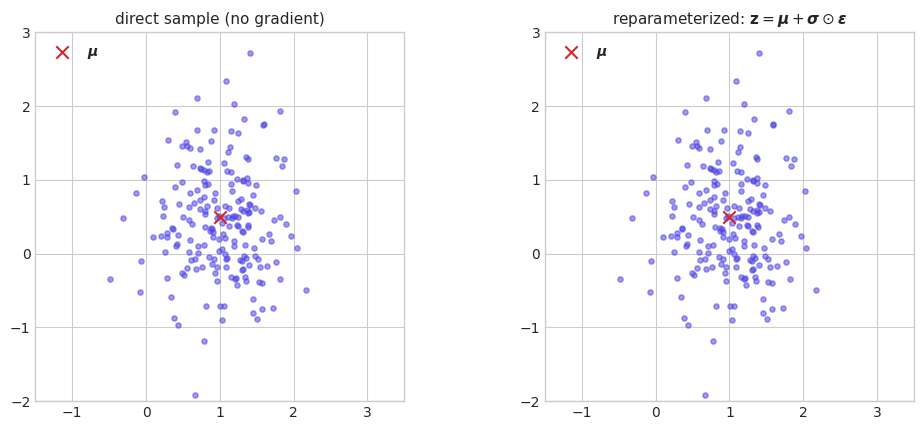

In [3]:
mu_v    = torch.tensor([1.0, 0.5], requires_grad=True)
sigma_v = torch.tensor([0.5, 0.8], requires_grad=True)

torch.manual_seed(7)
# Direct sample (would not allow backprop into mu, sigma)
direct = torch.normal(mu_v.expand(200, 2), sigma_v.expand(200, 2)).detach()

# Reparameterized sample — fully differentiable
torch.manual_seed(7)
eps = torch.randn(200, 2)
reparam = mu_v + sigma_v * eps

print('grad_fn of direct sample :', None if direct.grad_fn is None else direct.grad_fn.name())
print('grad_fn of reparam sample:', reparam.grad_fn.name() if reparam.grad_fn else None)

# Backward through the reparam sample
loss = reparam.pow(2).sum()
loss.backward()
print('\nGradients exist after reparam:')
print('  d loss / d mu    =', mu_v.grad.tolist())
print('  d loss / d sigma =', sigma_v.grad.tolist())

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.4))
for ax, pts, title in zip(axes,
                          [direct.numpy(), reparam.detach().numpy()],
                          ['direct sample (no gradient)', 'reparameterized: $\\mathbf{z} = \\boldsymbol{\\mu} + \\boldsymbol{\\sigma}\\odot\\boldsymbol{\\epsilon}$']):
    ax.scatter(pts[:, 0], pts[:, 1], s=14, alpha=0.55, color='#4f46e5')
    ax.scatter(*mu_v.detach().tolist(), color='#d62728', s=80, marker='x', label='$\\boldsymbol{\\mu}$', zorder=5)
    ax.set_title(title)
    ax.set_xlim(-1.5, 3.5); ax.set_ylim(-2.0, 3.0)
    ax.set_aspect('equal')
    ax.legend(loc='upper left')
plt.tight_layout(); plt.show()


The two clouds look the same — but only the right one carries gradients back to $\boldsymbol{\mu}, \boldsymbol{\sigma}$. The reparameterization trick makes the entire VAE end-to-end differentiable.

#### A cleaner numerical parameterization: `logvar`

In code we usually parameterize the encoder to output $\log \boldsymbol{\sigma}^2$ rather than $\boldsymbol{\sigma}$ directly:

- It can take any real value (no need for `softplus` or `exp` clamps).
- $\sigma = \exp(\tfrac{1}{2}\log\sigma^2)$ is always positive.
- The KL term simplifies nicely: $\mu^2 + \sigma^2 - 1 - \log\sigma^2 = \mu^2 + e^{\text{logvar}} - 1 - \text{logvar}$.


## Step 7 — The Full VAE Loss

Putting steps 4–6 together, the per-example **negative ELBO** that we minimise is

$$
-\mathcal{L}(\theta,\phi;\mathbf{x})
= \tfrac{1}{2\sigma^2}\,\|\mathbf{x} - f_\theta(\mathbf{z})\|_2^2
\;+\; \tfrac{1}{2}\sum_\ell \big(\mu_\ell^2 + e^{\ell_\ell} - 1 - \ell_\ell\big),
\quad \mathbf{z} = \boldsymbol{\mu} + e^{\ell/2} \odot \boldsymbol{\epsilon}, \;\boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0},\mathbf{I}),
$$

where $\ell_\ell = \log\sigma^2_\ell$ is the encoder log-variance. We average over a mini-batch.


## Step 8 — A Synthetic Single-Cell Dataset

We reuse the same cell-cycle ring that drives §20.3 in the book: a 2-D latent state generates a 64-gene profile via a random non-linear projection. The latent manifold is a curved ring — easy to visualise but impossible for a *linear* model to unfold.


cells: 3000   ·   genes: 64   ·   train/val: 2400/600


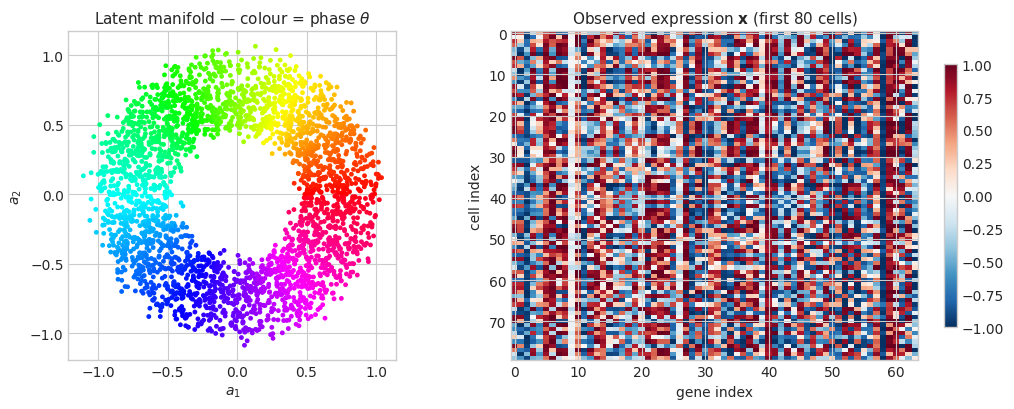

In [4]:
def make_cells(N, D, noise=0.05, seed=0):
    rng = np.random.default_rng(seed)
    theta = rng.uniform(0, 2 * np.pi, N)
    r = rng.uniform(0.5, 1.0, N) + 0.05 * rng.standard_normal(N)
    a = np.stack([
        r * np.cos(theta),
        r * np.sin(theta),
        r,
        np.sin(2 * theta),
    ], axis=1)
    W_gen = rng.standard_normal((D, 4))
    X = np.tanh(a @ W_gen.T) + noise * rng.standard_normal((N, D))
    return X.astype(np.float32), theta.astype(np.float32), r.astype(np.float32)

N, D = 3000, 64
X, theta, r = make_cells(N, D, noise=0.05, seed=0)

perm = np.random.permutation(N)
n_tr = 2400
tr, val = perm[:n_tr], perm[n_tr:]

X_t = torch.from_numpy(X)
loader = DataLoader(TensorDataset(X_t[tr]), batch_size=128, shuffle=True)

print(f'cells: {N}   ·   genes: {D}   ·   train/val: {n_tr}/{N - n_tr}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].scatter(np.cos(theta) * r, np.sin(theta) * r, c=theta, cmap='hsv', s=6)
axes[0].set_title('Latent manifold — colour = phase $\\theta$')
axes[0].set_aspect('equal'); axes[0].set_xlabel('$a_1$'); axes[0].set_ylabel('$a_2$')

im = axes[1].imshow(X[:80], aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
axes[1].set_xlabel('gene index'); axes[1].set_ylabel('cell index')
axes[1].set_title('Observed expression $\\mathbf{x}$ (first 80 cells)')
plt.colorbar(im, ax=axes[1], shrink=0.8)
plt.tight_layout(); plt.show()


## Step 9 — VAE in PyTorch

The implementation maps one-to-one to the equations:

| math object | code |
|---|---|
| encoder $\boldsymbol{\mu}_\phi(\mathbf{x}), \log\boldsymbol{\sigma}^2_\phi(\mathbf{x})$ | `self.encoder` → `fc_mu`, `fc_logvar` |
| reparam $\mathbf{z} = \boldsymbol{\mu} + e^{\ell/2}\odot\boldsymbol{\epsilon}$ | `reparam(mu, logvar)` |
| decoder $f_\theta(\mathbf{z})$ | `self.decoder` |
| reconstruction term | `((recon - x)**2).sum(1).mean()` |
| KL term | `-0.5 * (1 + logvar - mu**2 - logvar.exp()).sum(1).mean()` |


In [5]:
class VAE(nn.Module):
    def __init__(self, D, hidden=64, L=2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(D, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
        )
        self.fc_mu     = nn.Linear(hidden, L)
        self.fc_logvar = nn.Linear(hidden, L)
        self.decoder = nn.Sequential(
            nn.Linear(L, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, D),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparam(self, mu, logvar):
        std = (0.5 * logvar).exp()
        eps = torch.randn_like(std)
        return mu + std * eps

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparam(mu, logvar)
        return self.decode(z), mu, logvar


def vae_loss(recon, x, mu, logvar, beta=1.0):
    rec = ((recon - x) ** 2).sum(dim=1).mean()
    kl  = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).sum(dim=1).mean()
    return rec + beta * kl, rec, kl


## Step 10 — Training

Adam, 300 epochs, $\beta = 1$. Watch the two terms separately — both should drop, with the KL settling at a non-trivial positive value. A KL that crashes to zero is **posterior collapse**: the encoder ignores the input and matches the prior, leaving the decoder to fend for itself. We come back to this in step 13.


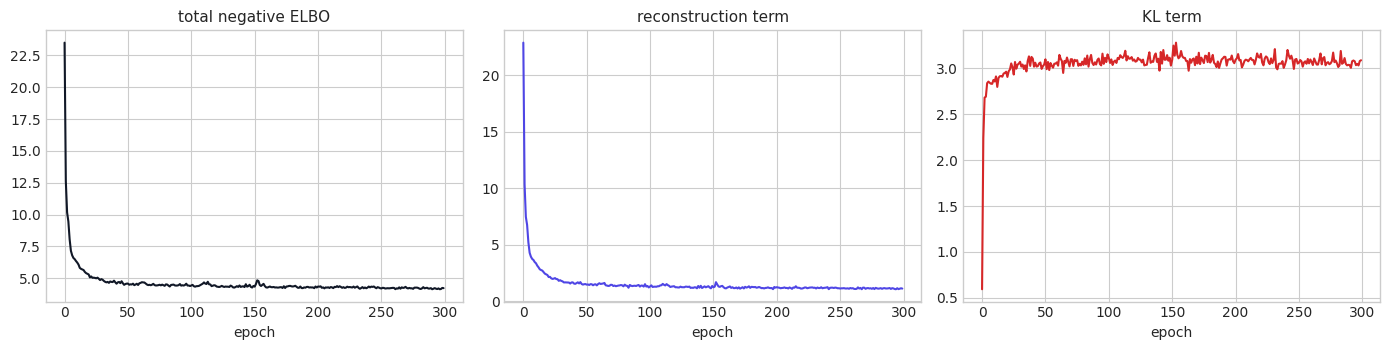

final reconstruction: 1.1397
final KL            : 3.0859


In [6]:
vae = VAE(D, hidden=64, L=2)
opt = torch.optim.Adam(vae.parameters(), lr=2e-3)

hist_total, hist_rec, hist_kl = [], [], []
for ep in range(300):
    tot = rec_s = kl_s = 0.0
    for (xb,) in loader:
        opt.zero_grad()
        recon, mu, logvar = vae(xb)
        loss, rec, kl = vae_loss(recon, xb, mu, logvar, beta=1.0)
        loss.backward(); opt.step()
        n = xb.size(0)
        tot += loss.item() * n; rec_s += rec.item() * n; kl_s += kl.item() * n
    hist_total.append(tot / n_tr); hist_rec.append(rec_s / n_tr); hist_kl.append(kl_s / n_tr)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
axes[0].plot(hist_total, color='#111827'); axes[0].set_title('total negative ELBO')
axes[1].plot(hist_rec,   color='#4f46e5'); axes[1].set_title('reconstruction term')
axes[2].plot(hist_kl,    color='#d62728'); axes[2].set_title('KL term')
for ax in axes: ax.set_xlabel('epoch')
plt.tight_layout(); plt.show()

print(f'final reconstruction: {hist_rec[-1]:.4f}')
print(f'final KL            : {hist_kl[-1]:.4f}')


## Step 11 — Visualizing the Latent Space

We plot the encoder mean $\boldsymbol{\mu}_\phi(\mathbf{x})$ for every validation cell, coloured by the true cell-cycle phase $\theta$. A working VAE should:

- arrange cells in a smooth ring (the underlying manifold);
- keep the cloud roughly inside the unit ball (KL pressure);
- fill the latent space densely — gaps are zones where samples from the prior do not decode into realistic cells.


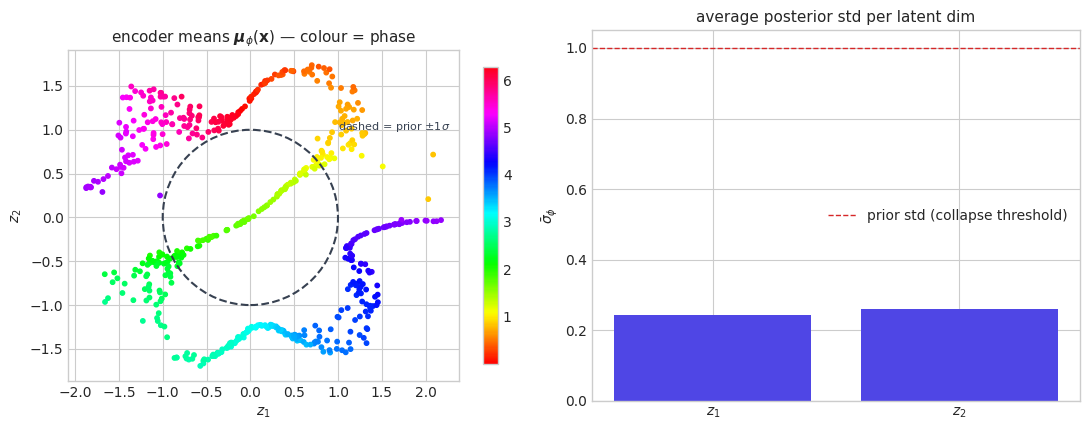

In [7]:
with torch.no_grad():
    mu_v, logvar_v = vae.encode(X_t[val])
Z = mu_v.numpy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))

sc = axes[0].scatter(Z[:, 0], Z[:, 1], c=theta[val], cmap='hsv', s=10)
prior_circle = plt.Circle((0, 0), 1.0, fill=False, lw=1.5, ls='--', color='#374151')
axes[0].add_patch(prior_circle)
axes[0].set_title('encoder means $\\boldsymbol{\\mu}_\\phi(\\mathbf{x})$ — colour = phase')
axes[0].set_aspect('equal'); axes[0].set_xlabel('$z_1$'); axes[0].set_ylabel('$z_2$')
axes[0].text(1.0, 1.0, 'dashed = prior $\\pm 1\\sigma$', fontsize=8, color='#374151')
plt.colorbar(sc, ax=axes[0], shrink=0.8)

# Per-dim posterior std averaged over validation cells
sigma_avg = (0.5 * logvar_v).exp().mean(0).numpy()
axes[1].bar(range(len(sigma_avg)), sigma_avg, color='#4f46e5')
axes[1].set_xticks(range(len(sigma_avg)))
axes[1].set_xticklabels([f'$z_{{{i+1}}}$' for i in range(len(sigma_avg))])
axes[1].axhline(1.0, color='#d62728', ls='--', lw=1, label='prior std (collapse threshold)')
axes[1].set_title('average posterior std per latent dim')
axes[1].set_ylabel('$\\bar{\\sigma}_\\phi$')
axes[1].legend()
plt.tight_layout(); plt.show()


**Reading the right panel.** A latent dimension whose posterior std sits at $\approx 1$ is **collapsed** — the encoder is ignoring the input and just outputting the prior. Useful dimensions have $\bar{\sigma}_\phi < 1$ because they carry information about $\mathbf{x}$ (KL > 0).


## Step 12 — Sampling and Interpolation

This is what a VAE buys you over a vanilla AE. Both are demos of the **generative** capability.

### 12a) Prior samples

Draw $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ and decode. Each row below is one synthetic cell — these were never seen in training.


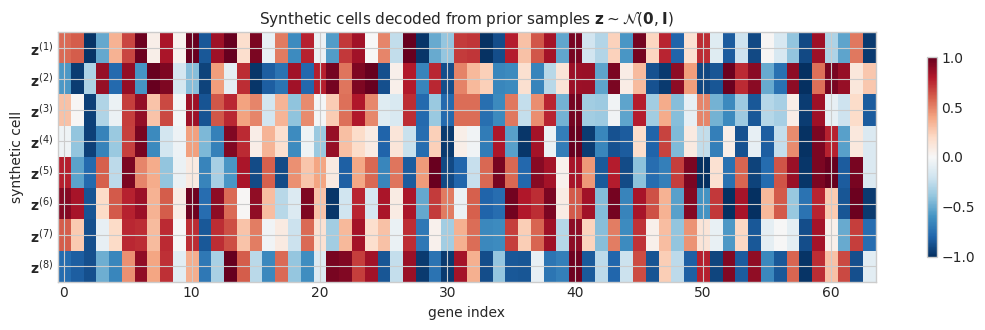

In [8]:
with torch.no_grad():
    z_prior = torch.randn(8, 2)
    x_synth = vae.decode(z_prior).numpy()

fig, ax = plt.subplots(1, 1, figsize=(11, 3.4))
im = ax.imshow(x_synth, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xlabel('gene index'); ax.set_ylabel('synthetic cell')
ax.set_yticks(range(8)); ax.set_yticklabels([f'$\\mathbf{{z}}^{{({i+1})}}$' for i in range(8)])
ax.set_title('Synthetic cells decoded from prior samples $\\mathbf{z} \\sim \\mathcal{N}(\\mathbf{0},\\mathbf{I})$')
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()


### 12b) Latent interpolation — a smooth biological trajectory

Pick two cells on opposite sides of the cell-cycle ring, encode them, and traverse the latent line between their posterior means. Decoding each waypoint gives a synthetic cell smoothly morphing from one phase to the other.


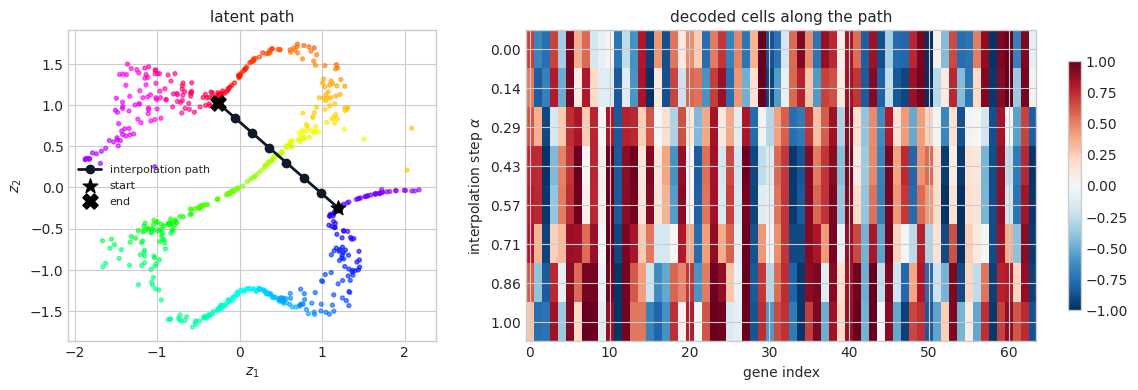

In [9]:
i, j = 7, 1234
x1 = X_t[i:i+1]; x2 = X_t[j:j+1]
with torch.no_grad():
    mu1, _ = vae.encode(x1)
    mu2, _ = vae.encode(x2)
    alphas = torch.linspace(0, 1, 8).unsqueeze(1)
    z_path = (1 - alphas) * mu1 + alphas * mu2
    x_path = vae.decode(z_path).numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.0), gridspec_kw={'width_ratios': [1, 1.6]})

axes[0].scatter(Z[:, 0], Z[:, 1], c=theta[val], cmap='hsv', s=8, alpha=0.6)
axes[0].plot(z_path[:, 0], z_path[:, 1], '-o', color='#111827', lw=2, ms=6, label='interpolation path')
axes[0].scatter(*mu1.numpy().flatten(), s=120, marker='*', color='black', zorder=5, label='start')
axes[0].scatter(*mu2.numpy().flatten(), s=120, marker='X', color='black', zorder=5, label='end')
axes[0].set_aspect('equal'); axes[0].set_title('latent path'); axes[0].legend(fontsize=8)
axes[0].set_xlabel('$z_1$'); axes[0].set_ylabel('$z_2$')

im = axes[1].imshow(x_path, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
axes[1].set_xlabel('gene index'); axes[1].set_ylabel('interpolation step $\\alpha$')
axes[1].set_yticks(range(8))
axes[1].set_yticklabels([f'{a:.2f}' for a in np.linspace(0, 1, 8)])
axes[1].set_title('decoded cells along the path')
plt.colorbar(im, ax=axes[1], shrink=0.8)
plt.tight_layout(); plt.show()


## Step 13 — Posterior Collapse and the $\beta$-VAE

In the loss

$$
-\mathcal{L} = \underbrace{\text{recon}}_{\text{wants info in } \mathbf{z}} + \;\beta\!\cdot\!\underbrace{D_{\mathrm{KL}}(q_\phi\|p)}_{\text{wants } \mathbf{z} \approx \text{prior}},
$$

raising $\beta$ pulls every posterior $q_\phi(\mathbf{z}\mid\mathbf{x})$ closer to the prior $\mathcal{N}(\mathbf{0},\mathbf{I})$. Pushed too far, the encoder gives up and returns the prior verbatim — the encoder mean clusters at the origin and the variance climbs to 1. Reconstruction quality collapses with it.

Let us train two extra VAEs with $\beta \in \{0.1, 6\}$ and compare.


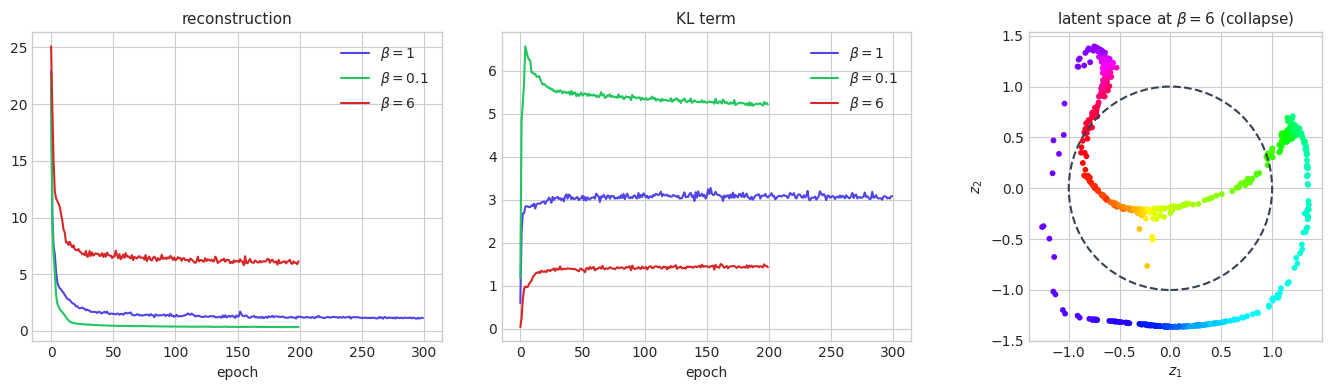

final KL  ·  beta=0.1 : 5.219
final KL  ·  beta=1.0 : 3.086
final KL  ·  beta=6.0 : 1.433


In [10]:
def train_vae(beta, epochs=200, seed=0):
    torch.manual_seed(seed)
    m = VAE(D, hidden=64, L=2)
    o = torch.optim.Adam(m.parameters(), lr=2e-3)
    rec_h, kl_h = [], []
    for _ in range(epochs):
        rec_s = kl_s = 0.0
        for (xb,) in loader:
            o.zero_grad()
            recon, mu, lv = m(xb)
            _, rec, kl = vae_loss(recon, xb, mu, lv, beta=beta)
            (rec + beta * kl).backward(); o.step()
            n = xb.size(0)
            rec_s += rec.item() * n; kl_s += kl.item() * n
        rec_h.append(rec_s / n_tr); kl_h.append(kl_s / n_tr)
    return m, rec_h, kl_h

m_low,  rec_lo, kl_lo = train_vae(beta=0.1)
m_high, rec_hi, kl_hi = train_vae(beta=6.0)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.0))

for h_rec, h_kl, label, color in [
    (hist_rec, hist_kl, '$\\beta = 1$', '#4f46e5'),
    (rec_lo,   kl_lo,   '$\\beta = 0.1$', '#22c55e'),
    (rec_hi,   kl_hi,   '$\\beta = 6$',   '#d62728'),
]:
    axes[0].plot(h_rec, label=label, color=color)
    axes[1].plot(h_kl,  label=label, color=color)

axes[0].set_title('reconstruction'); axes[0].legend(); axes[0].set_xlabel('epoch')
axes[1].set_title('KL term');         axes[1].legend(); axes[1].set_xlabel('epoch')

# Encoder means for the high-beta model — should look collapsed
with torch.no_grad():
    Z_hi, _ = m_high.encode(X_t[val])
Z_hi = Z_hi.numpy()
sc = axes[2].scatter(Z_hi[:, 0], Z_hi[:, 1], c=theta[val], cmap='hsv', s=10)
axes[2].add_patch(plt.Circle((0, 0), 1.0, fill=False, lw=1.5, ls='--', color='#374151'))
axes[2].set_aspect('equal'); axes[2].set_title('latent space at $\\beta = 6$ (collapse)')
axes[2].set_xlabel('$z_1$'); axes[2].set_ylabel('$z_2$')
plt.tight_layout(); plt.show()

print(f'final KL  ·  beta=0.1 : {kl_lo[-1]:.3f}')
print(f'final KL  ·  beta=1.0 : {hist_kl[-1]:.3f}')
print(f'final KL  ·  beta=6.0 : {kl_hi[-1]:.3f}')


**Read-out.** With $\beta = 0.1$ the KL term is much larger and reconstruction is best — the model behaves more like a plain AE. With $\beta = 6$ the KL crashes towards zero, the latent code shrinks to a tiny blob, and reconstruction suffers. The textbook $\beta = 1$ sits in between, generating a balanced latent space we can sample from.

A common production trick is **KL annealing** — start with $\beta \approx 0$ and ramp it up over the first epochs, so the encoder learns to use $\mathbf{z}$ before the KL pressure kicks in.


## Summary

We turned a deterministic autoencoder into a probabilistic generative model in seven steps:

1. **Generative model**: $\mathbf{z}\sim\mathcal{N}(\mathbf{0},\mathbf{I})$, $\mathbf{x}\mid\mathbf{z}\sim\mathcal{N}(f_\theta(\mathbf{z}),\sigma^2 I)$.
2. **Variational posterior**: $q_\phi(\mathbf{z}\mid\mathbf{x}) = \mathcal{N}(\boldsymbol{\mu}_\phi(\mathbf{x}),\mathrm{diag}(\boldsymbol{\sigma}^2_\phi(\mathbf{x})))$.
3. **ELBO**: $\mathcal{L} = \mathbb{E}_{q_\phi}[\log p_\theta(\mathbf{x}\mid\mathbf{z})] - D_{\mathrm{KL}}(q_\phi\,\|\,p)$.
4. **Closed-form KL** between two diagonal Gaussians: $\tfrac{1}{2}\sum(\mu^2 + e^\ell - 1 - \ell)$.
5. **Monte-Carlo reconstruction** via one sample per data point.
6. **Reparameterization** $\mathbf{z} = \boldsymbol{\mu} + e^{\ell/2}\odot\boldsymbol{\epsilon}$ — keeps gradients flowing through the encoder.
7. **Training and exploration**: smooth latent ring, prior sampling, latent interpolation, $\beta$-VAE trade-off and posterior collapse.

**Where to go next.** Discrete or count likelihoods (Bernoulli, Poisson, NB) for raw scRNA-seq counts; VAEs with normalising-flow posteriors for richer $q_\phi$; conditional VAEs that take side information $\mathbf{c}$ (e.g. drug treatment) into the encoder and decoder.
